In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

## Part 1 : Stock prices and news

1. View tickers and price trends

/var/folders/vj/1dzb5n4d64vd6jbcprcbjkjc0000gn/T/ipykernel_87648/1672139258.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  prices["Date"] = pd.to_datetime(prices["Date"])


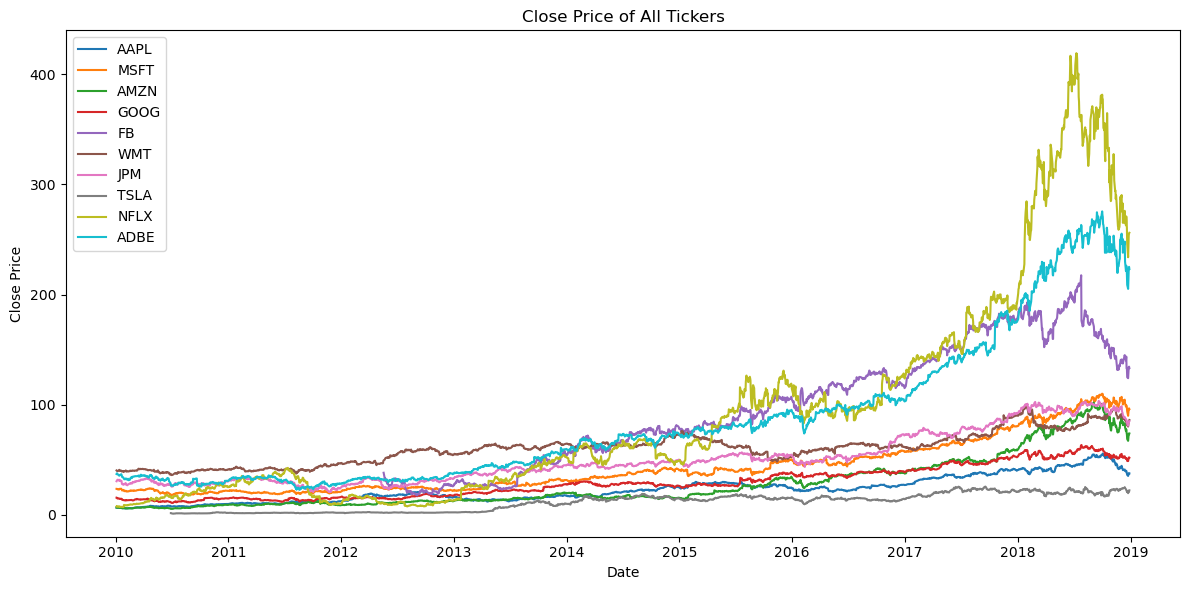

In [9]:
DATA_DIR = Path("../data/")

prices = pd.read_csv(DATA_DIR / 'prices_data.csv')
prices["Date"] = pd.to_datetime(prices["Date"])

tickers = prices["ticker"].unique()
plt.figure(figsize=(12, 6))

for t in tickers:
    sub = prices[prices["ticker"] == t].sort_values("Date")
    plt.plot(sub["Date"], sub["Close"], label=t)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Close Price of All Tickers")
plt.tight_layout()
plt.show()

2. Prepare news data

In [10]:
headlines = pd.read_csv(DATA_DIR / "headlines.csv")

# clean headlines
headlines = headlines.dropna(subset=["ticker", "headline"])
headlines = headlines[headlines["ticker"].str.strip() != ""]
headlines = headlines[headlines["headline"].str.strip() != ""]
headlines["ticker"] = headlines["ticker"].str.strip().str.upper()
headlines["date"] = pd.to_datetime(headlines["date"]).dt.date

headlines.head()

,ticker,headline,date
0,DVA,Davita (NYSE:DVA): EPS of $0.96 beats by $0.01...,2011-05-02
1,CGNX,Cognex (NASDAQ:CGNX): EPS of $0.32 beats by $0...,2011-05-02
2,AEIS,Advanced Energy Industries (NASDAQ:AEIS):,2011-05-02
3,LOCM,Local.com (NASDAQ:LOCM):,2011-05-02
4,CYDEQ,CyberDefender (CYDE):,2011-05-02


3. Prepare prices data

In [19]:
prices["Date"] = pd.to_datetime(prices["Date"],  utc=True)
prices["date"] = prices["Date"].dt.date

# sort by date, calculate daily return
prices = prices.sort_values(["ticker", "Date"])
prices["ret"] = prices.groupby("ticker")["Close"].pct_change()

g = prices.groupby("ticker")["ret"]
prices["ret_m1"] = g.shift(1)    # t-1
prices["ret_p1"] = g.shift(-1)   # t+1
prices["ret_p2"] = g.shift(-2)   # t+2
prices["ret_p3"] = g.shift(-3)   # t+3

prices["CAR_m1_p3"] = (
    prices["ret_m1"]
    + prices["ret"]
    + prices["ret_p1"]
    + prices["ret_p2"]
    + prices["ret_p3"]
)

price_cols = ["ticker", "date", "Close", "CAR_m1_p3"]
prices_small = prices[price_cols].copy()

prices_small.head()

,ticker,date,Close,CAR_m1_p3
0,AAPL,2010-01-04,6.505279,NaN
1,AAPL,2010-01-05,6.516527,NaN
2,AAPL,2010-01-06,6.412873,-0.018199
3,AAPL,2010-01-07,6.401018,-0.031303
4,AAPL,2010-01-08,6.443573,-0.001292


4. Merge prices and news

In [21]:
df_all = pd.merge(
    headlines, prices_small, 
    on=["ticker", "date"],
    how="left"
)

df_all = df_all.dropna(subset=["CAR_m1_p3"]).reset_index(drop=True)
df_all = df_all.rename(columns={"CAR_m1_p3": "eventRet"})

df_all.head(), df_all.shape
df_all.to_csv(DATA_DIR / "combined_car_m1_p3.csv", index=False)

## Part 2: Sentiment Information